# Машинное обучение, ВШЭ 2026
## Семинар 6. Классификация текстов: Bag of Words и TF-IDF

**Автор версии 2026:** Иван Горбунов

Семинар собран на основе материала курса ML ВШЭ 2024 «Introduction to NLP» (авторы оригинала — Мария Тихонова, Евгений Соколов), переработан и обновлён: новый порядок блоков, актуальные версии библиотек, замеры вместо «так принято».

<a href="https://colab.research.google.com/github/paiflare/ml_hse_2026/blob/master/week06/06_Text_Classification_BoW_TFIDF.ipynb" target="_blank">Открыть в Colab</a>

### О чём сегодня

Все модели, которые мы проходили, едят таблицу чисел. Текст — не таблица чисел. Весь семинар про одно: **как превратить текст в матрицу признаков так, чтобы обычный логрег на ней заработал.**

Задача-полигон: определить тональность новости (`negative` / `neutral` / `positive`) по её тексту.

### План и тайминг (80 минут)

| # | Блок | ⏱ |
|---|------|---|
| 1 | Данные: что внутри, как выглядит | 8 мин |
| 2 | Бейзлайн за пять строк | 7 мин |
| 3 | Bag of Words: что там под капотом | 12 мин |
| 4 | TF-IDF: почему просто счётчики — плохо | 12 мин |
| 5 | Нормализация текста: лемматизация и стоп-слова | 12 мин |
| 6 | Что реально двигает метрику | 10 мин |
| 7 | Интерпретация и разбор ошибок | 12 мин |
| 8 | Почему здесь не работают деревья | 7 мин |

Задачи для самостоятельной работы — в конце ноутбука.

In [1]:
# в Colab раскомментируйте:
# !pip install -q pymorphy3

import json
import re
import time
import urllib.request
from functools import lru_cache
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (9, 4)
RANDOM_STATE = 42

---
## 1. Данные ⏱ 8 мин

Датасет — новости на русском с разметкой тональности ([соревнование на Kaggle](https://www.kaggle.com/c/sentiment-analysis-in-russian/data)). Файл около 57 МБ, качаем один раз и кладём рядом с ноутбуком.

In [2]:
URL_DATA = (
    'https://raw.githubusercontent.com/hushchyn-mikhail/hse_se_ml/'
    's08/2020/s08-nlp/Data/train.json'
)
DATA_PATH = Path('train.json')

if not DATA_PATH.exists():
    print('качаем данные...')
    urllib.request.urlretrieve(URL_DATA, DATA_PATH)

with open(DATA_PATH, encoding='utf-8') as f:
    data = json.load(f)

print('новостей:', len(data))
print('поля:', list(data[0].keys()))

новостей: 8263
поля: ['text', 'id', 'sentiment']


In [3]:
df = pd.DataFrame(data)
df.head(3)

,text,id,sentiment
0,Досудебное расследование по факту покупки ЕНПФ...,1945,negative
1,Медики рассказали о состоянии пострадавшего му...,1957,negative
2,"Прошел почти год, как железнодорожным оператор...",1969,negative


In [4]:
# распределение классов — почти всегда первое, на что смотрят в классификации
df['sentiment'].value_counts()

sentiment
neutral     4034
positive    2795
negative    1434
Name: count, dtype: int64

Классы несбалансированы: нейтральных почти половина, негативных — меньше пятой части. Запомните это, к `class_weight` и к выбору метрики мы вернёмся уже через десять минут.

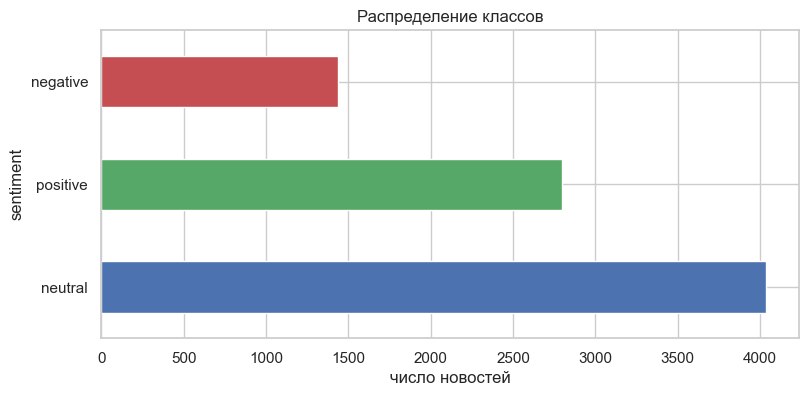

In [5]:
ax = df['sentiment'].value_counts().plot(kind='barh', color=['#4C72B0', '#55A868', '#C44E52'])
ax.set_title('Распределение классов')
ax.set_xlabel('число новостей')
plt.show()

In [6]:
# посмотрим на живой пример
row = df.iloc[1]
print('Тональность:', row['sentiment'], '\n')
print(row['text'][:700], '...')

Тональность: negative 

Медики рассказали о состоянии пострадавшего мужчины, на которого было совершено нападение возле отделения банка по Тимирязева. Как прокомментировали Tengrinews.kz в пресс-службе Управления здравоохранения Алматы, с места происшествия в службу скорой помощи обратились двое человек. 

«Одному из них на месте была оказана медицинская помощь. От госпитализации он отказался. Второй пациент был доставлен в больницу скорой неотложной помощи (БСНП) с сотрясением головного мозга, ушибленной раной головы. Состояние на данный момент оценивается ближе к удовлетворительному. Пока он проходит обследование в больнице», — сообщили в Управлении здравоохранения Алматы.  

Напомним, в Алматы на пересечении ули ...


In [7]:
df['n_words'] = df['text'].str.split().str.len()
print(df['n_words'].describe().round(1))

count     8263.0
mean       511.7
std       1168.1
min          4.0
25%        164.0
50%        271.0
75%        481.0
max      48146.0
Name: n_words, dtype: float64


Медиана — около 270 слов, но есть выбросы в десятки тысяч. Это не твиты, а полноценные новостные заметки: тональность может прятаться в одном абзаце из пяти.

> **Вопрос залу.** Если бы мы решали задачу «вручную» — по каким словам вы бы отличали негативную новость от нейтральной? Запомните свои гипотезы, в блоке 7 сравним их с тем, что реально выучила модель.

---
## 2. Бейзлайн за пять строк ⏱ 7 мин

Соблазн начать с трёх часов предобработки велик, но правильный порядок другой: **сначала самый тупой рабочий бейзлайн, потом улучшения** — иначе не с чем сравнивать.

Берём `TfidfVectorizer` + `LogisticRegression` и даже не смотрим, что внутри. Разбираться будем после того, как увидим число.

In [8]:
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline
from sklearn.metrics import f1_score, accuracy_score, classification_report

X_train, X_test, y_train, y_test = train_test_split(
    df['text'].tolist(), df['sentiment'].tolist(),
    test_size=0.2, random_state=RANDOM_STATE, stratify=df['sentiment'],
)
print('train:', len(X_train), ' test:', len(X_test))

train: 6610  test: 1653


In [9]:
baseline = make_pipeline(
    TfidfVectorizer(max_features=50_000),
    LogisticRegression(max_iter=1000, class_weight='balanced'),
)

t0 = time.time()
baseline.fit(X_train, y_train)
pred = baseline.predict(X_test)

print(f'обучение заняло {time.time() - t0:.1f} с')
print(f'accuracy = {accuracy_score(y_test, pred):.3f}')
print(f'f1_macro = {f1_score(y_test, pred, average="macro"):.3f}')

обучение заняло 2.5 с
accuracy = 0.712
f1_macro = 0.713


Всё. Текст ни разу не был почищен, стоп-слова не удалены, лемматизации нет — а модель уже работает.

Но 0.71 — это много или мало? Нужна точка отсчёта: модель, которая всегда предсказывает самый частый класс.

In [10]:
from sklearn.dummy import DummyClassifier

dummy = make_pipeline(TfidfVectorizer(max_features=1000), DummyClassifier(strategy='most_frequent'))
dummy.fit(X_train, y_train)
dummy_pred = dummy.predict(X_test)

print(f'Dummy:   accuracy = {accuracy_score(y_test, dummy_pred):.3f}, '
      f'f1_macro = {f1_score(y_test, dummy_pred, average="macro"):.3f}')
print(f'LogReg:  accuracy = {accuracy_score(y_test, pred):.3f}, '
      f'f1_macro = {f1_score(y_test, pred, average="macro"):.3f}')

Dummy:   accuracy = 0.488, f1_macro = 0.219
LogReg:  accuracy = 0.712, f1_macro = 0.713


Вот зачем нужен `f1_macro`: по accuracy константная модель выглядит почти прилично (48% — это просто доля класса `neutral`), а по macro-F1 её отрыв от реальной модели становится честным. **На несбалансированных классах accuracy врёт.**

Дальше мы будем сравнивать варианты векторизации десяток раз, поэтому сразу заведём функцию, которая обучает пайплайн и печатает метрику со временем.

In [11]:
def evaluate(name, vectorizer, model=None, corpus_train=None, corpus_test=None):
    """Обучает пайплайн, печатает метрику и время. Возвращает словарь с результатом."""
    model = model or LogisticRegression(max_iter=1000, class_weight='balanced')
    corpus_train = corpus_train if corpus_train is not None else X_train
    corpus_test = corpus_test if corpus_test is not None else X_test

    t0 = time.time()
    pipe = make_pipeline(vectorizer, model).fit(corpus_train, y_train)
    prediction = pipe.predict(corpus_test)
    elapsed = time.time() - t0

    f1 = f1_score(y_test, prediction, average='macro')
    print(f'{name:<34} f1_macro = {f1:.3f}   ({elapsed:.1f} с)')
    return {'название': name, 'f1_macro': round(f1, 3), 'секунд': round(elapsed, 1), 'pipe': pipe}


results = []

---
## 3. Bag of Words: что под капотом ⏱ 12 мин

Идея «мешка слов» простая до наглости:

1. собираем словарь всех слов корпуса;
2. каждый документ — вектор длины «размер словаря»;
3. в позиции слова стоит, сколько раз оно встретилось в документе.

Порядок слов при этом теряется полностью. «Собака укусила человека» и «человек укусил собаку» дают один и тот же вектор. Мешок — он и есть мешок.

Посмотрим на четырёх игрушечных предложениях.

In [12]:
from sklearn.feature_extraction.text import CountVectorizer

toy = [
    'кот сидит на окне',
    'кот сидит на столе',
    'собака громко лает во дворе',
    'собака и кот не поделили окно',
]

cv = CountVectorizer()
toy_matrix = cv.fit_transform(toy)

pd.DataFrame(
    toy_matrix.toarray(),
    columns=cv.get_feature_names_out(),
    index=[f'док {i}' for i in range(len(toy))],
)

,во,громко,дворе,кот,лает,на,не,окне,окно,поделили,сидит,собака,столе
док 0,0,0,0,1,0,1,0,1,0,0,1,0,0
док 1,0,0,0,1,0,1,0,0,0,0,1,0,1
док 2,1,1,1,0,1,0,0,0,0,0,0,1,0
док 3,0,0,0,1,0,0,1,0,1,1,0,1,0


Каждая строка — документ, каждый столбец — слово из словаря. Обратите внимание на две вещи: матрица почти вся из нулей, и слово «окне» с «окно» попали в разные столбцы — для `CountVectorizer` это два никак не связанных признака.

Посмотрим, насколько разрежена настоящая матрица на наших новостях.

In [13]:
cv_real = CountVectorizer(max_features=30_000, min_df=3)
counts = cv_real.fit_transform(X_train)

print('размер матрицы:', counts.shape)
density = counts.nnz / (counts.shape[0] * counts.shape[1])
print(f'ненулевых значений: {counts.nnz:,} — это {density:.2%} матрицы')
print(f'если хранить плотно: {counts.shape[0] * counts.shape[1] * 8 / 1e9:.1f} ГБ')
print(f'разреженно (как есть): {counts.data.nbytes / 1e6:.1f} МБ')

размер матрицы: (6610, 30000)
ненулевых значений: 1,681,316 — это 0.85% матрицы
если хранить плотно: 1.6 ГБ
разреженно (как есть): 13.5 МБ


Меньше процента заполнения. Именно поэтому `scikit-learn` возвращает не `numpy`-массив, а **разреженную матрицу** `scipy.sparse`: плотно эти данные просто не поместились бы в память.

> **Практический вывод.** Не зовите `.toarray()` на реальной матрице признаков. На игрушечном примере — пожалуйста, на 30 тысячах признаков — это моментальный `MemoryError`.

Обучим логрег прямо на счётчиках, чтобы было с чем сравнивать TF-IDF.

In [14]:
results.append(evaluate('Счётчики (BoW)', CountVectorizer(max_features=30_000, min_df=3)))

/Users/ivangorbunov/.venvs/ml_hse_2026/lib/python3.11/site-packages/sklearn/linear_model/_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


Счётчики (BoW)                     f1_macro = 0.665   (16.4 с)


Хуже бейзлайна **и** заметно дольше учится. Почему — в следующем блоке.

---
## 4. TF-IDF ⏱ 12 мин

У голых счётчиков две беды:

1. **Частое ≠ важное.** Слова «в», «и», «на» встречаются в каждом документе и раздувают вектор, ничего не сообщая о классе.
2. **Длинный документ ≠ более выразительный.** Заметка на 3000 слов даёт числа в разы больше, чем на 200, хотя содержание может быть одинаковым.

TF-IDF чинит обе:

$$\text{tfidf}(t, d) = \underbrace{\text{tf}(t, d)}_{\text{частота в документе}} \times \underbrace{\log\frac{1 + n}{1 + \text{df}(t)} + 1}_{\text{редкость в корпусе}}$$

где $n$ — число документов, $\text{df}(t)$ — в скольких документах встретилось слово $t$. Плюс результат нормируется по длине документа.

Смысл: **слово ценно, если оно часто в этом документе и редко во всех остальных.** Посмотрим на idf на игрушечном корпусе.

In [15]:
tfidf_toy = TfidfVectorizer()
tfidf_toy.fit(toy)

idf = pd.Series(tfidf_toy.idf_, index=tfidf_toy.get_feature_names_out()).sort_values()
print('Самые "дешёвые" слова (есть почти везде):')
print(idf.head(4).round(2).to_string())
print('\nСамые "дорогие" слова (встретились один раз):')
print(idf.tail(4).round(2).to_string())

Самые "дешёвые" слова (есть почти везде):
кот       1.22
на        1.51
сидит     1.51
собака    1.51

Самые "дорогие" слова (встретились один раз):
окне        1.92
окно        1.92
поделили    1.92
столе       1.92


«Кот» есть в трёх документах из четырёх — его вес минимальный. «Лает» встретилось один раз — вес максимальный. Стоп-слова таким образом душатся автоматически, без всяких списков.

Проверим на реальных данных.

In [16]:
results.append(evaluate('TF-IDF', TfidfVectorizer(max_features=30_000, min_df=3)))

TF-IDF                             f1_macro = 0.710   (2.5 с)


TF-IDF выигрывает и по качеству, и по времени обучения: признаки отнормированы, оптимизатору логрега проще сходиться.

> **На заметку.** Если видите в логах `ConvergenceWarning` и «увеличьте max_iter» — часто дело не в числе итераций, а в ненормированных признаках.

---
## 5. Нормализация текста ⏱ 12 мин

Русский язык флективный: «банк», «банка», «банку», «банками» — для `CountVectorizer` это четыре независимых признака. Классический рецепт из учебников — свести словоформы к одной начальной форме. Два способа:

* **Стемминг** — грубо отрезать окончание по правилам. Быстро, но результат часто не слово: «обучение» → «обучен».
* **Лемматизация** — привести к словарной форме с помощью морфологического анализатора. Медленнее, зато «машинного» → «машинный».

Посмотрим на обоих.

In [17]:
from nltk.stem.snowball import SnowballStemmer

stemmer = SnowballStemmer('russian')
example = 'машинное обучение для анализа данных в высшей школе экономики'

print('было:    ', example)
print('стемминг:', ' '.join(stemmer.stem(w) for w in example.split()))

было:     машинное обучение для анализа данных в высшей школе экономики
стемминг: машин обучен для анализ дан в высш школ экономик


In [18]:
# pymorphy3 — актуальный форк pymorphy2 (тот не заводится на Python 3.11+)
import pymorphy3

morph = pymorphy3.MorphAnalyzer()

print('лемматизация:', ' '.join(morph.parse(w)[0].normal_form for w in example.split()))

лемматизация: машинный обучение для анализ данные в высокий школа экономика


Стемминг превратил фразу в кашу, лемматизация — читаемо. Для русского почти всегда берут лемматизацию.

Морфоанализатор небыстрый, но нас спасает то, что **слова повторяются**: достаточно разобрать каждое уникальное слово один раз и закэшировать. `lru_cache` делает это в одну строку.

In [19]:
TOKEN_RE = re.compile(r'[а-яёa-z]+')

@lru_cache(maxsize=None)
def lemmatize_word(word: str) -> str:
    return morph.parse(word)[0].normal_form

def normalize(text: str) -> str:
    """Нижний регистр -> токенизация регуляркой -> леммы -> обратно в строку."""
    return ' '.join(lemmatize_word(w) for w in TOKEN_RE.findall(text.lower()))

print(normalize('Курс доллара вырос на 3 процента, банки ожидают дальнейшего роста!'))

курс доллар вырасти на процент банк ожидать дальнейший рост


In [20]:
t0 = time.time()
X_train_lem = [normalize(t) for t in X_train]
X_test_lem = [normalize(t) for t in X_test]
print(f'лемматизация всего корпуса: {time.time() - t0:.1f} с')
print(f'уникальных слов в кэше: {lemmatize_word.cache_info().currsize:,}')

лемматизация всего корпуса: 7.8 с
уникальных слов в кэше: 142,763


Без кэша это заняло бы минуты — в оригинальной версии семинара лемматизированный корпус вообще приходилось скачивать готовым файлом.

А теперь — главный вопрос семинара: **лемматизация вообще помогает?**

In [21]:
results.append(evaluate(
    'TF-IDF + леммы', TfidfVectorizer(max_features=30_000, min_df=3),
    corpus_train=X_train_lem, corpus_test=X_test_lem,
))

TF-IDF + леммы                     f1_macro = 0.694   (2.0 с)


In [22]:
import nltk
nltk.download('stopwords', quiet=True)
russian_stopwords = nltk.corpus.stopwords.words('russian')
print('пример стоп-слов:', russian_stopwords[:12])

results.append(evaluate(
    'TF-IDF + леммы + стоп-слова',
    TfidfVectorizer(max_features=30_000, min_df=3, stop_words=russian_stopwords),
    corpus_train=X_train_lem, corpus_test=X_test_lem,
))

пример стоп-слов: ['и', 'в', 'во', 'не', 'что', 'он', 'на', 'я', 'с', 'со', 'как', 'а']


TF-IDF + леммы + стоп-слова        f1_macro = 0.695   (2.1 с)


### Стоп. Стало хуже

Лемматизация ухудшила метрику. Удаление стоп-слов её не спасло.

Это не баг ноутбука, это нормальный результат, и объяснение у него внятное:

* TF-IDF **уже** обесценивает частотные слова — отдельный список стоп-слов дублирует то, что и так работает;
* лемматизация **стирает информацию**: «выросли» и «вырастут» схлопываются в «вырасти», хотя прошедшее и будущее время в новостях означают разное;
* словоформы в новостях и так повторяются достаточно часто, чтобы модель видела каждую не по одному разу.

**Мораль семинара, которую стоит унести с собой:** «обязательный препроцессинг» из учебников — это гипотеза, а не аксиома. Гипотезу надо проверять замером, и у вас теперь есть функция `evaluate`, чтобы делать это за одну строчку.

---
## 6. Что реально двигает метрику ⏱ 10 мин

Раз чистка текста не сработала, попробуем то, что меняет саму матрицу признаков.

**N-граммы.** Мешок слов не видит порядка, но можно добавить в словарь пары соседних слов. Тогда «не вырос» станет отдельным признаком — и отрицания перестанут теряться.

In [23]:
cv_bigram = CountVectorizer(ngram_range=(1, 2))
cv_bigram.fit(['курс доллара не вырос'])
print(cv_bigram.get_feature_names_out())

['вырос' 'доллара' 'доллара не' 'курс' 'курс доллара' 'не' 'не вырос']


In [24]:
results.append(evaluate(
    'TF-IDF, слова + биграммы',
    TfidfVectorizer(ngram_range=(1, 2), min_df=3, max_features=200_000),
))

TF-IDF, слова + биграммы           f1_macro = 0.714   (8.1 с)


**Размер словаря.** `max_features` — сколько самых частых признаков оставить. Слишком мало — теряем сигнал, слишком много — шум и переобучение. Посмотрим на кривую.

In [25]:
grid = [500, 2_000, 10_000, 30_000, 100_000]
scores = []

for n in grid:
    pipe = make_pipeline(
        TfidfVectorizer(max_features=n),
        LogisticRegression(max_iter=1000, class_weight='balanced'),
    ).fit(X_train, y_train)
    scores.append(f1_score(y_test, pipe.predict(X_test), average='macro'))
    print(f'max_features={n:>7,}  f1_macro={scores[-1]:.3f}')

max_features=    500  f1_macro=0.618


max_features=  2,000  f1_macro=0.677


max_features= 10,000  f1_macro=0.698


max_features= 30,000  f1_macro=0.711


max_features=100,000  f1_macro=0.710


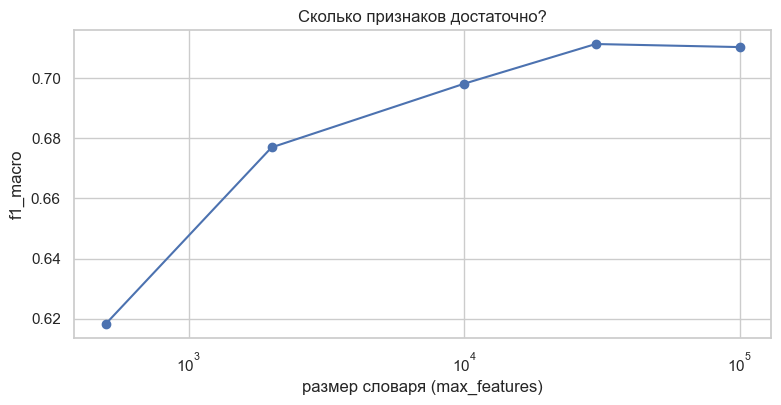

In [26]:
plt.plot(grid, scores, marker='o')
plt.xscale('log')
plt.xlabel('размер словаря (max_features)')
plt.ylabel('f1_macro')
plt.title('Сколько признаков достаточно?')
plt.show()

Кривая выходит на плато: после определённого размера словаря новые слова — это уже опечатки и имена собственные, встречающиеся по одному разу.

**Подбор C.** У логрега один по-настоящему важный гиперпараметр — сила регуляризации. Полный `GridSearchCV` по четырём осям на семинаре считался бы вечность, поэтому пройдёмся по одной.

In [27]:
from sklearn.model_selection import GridSearchCV

pipe = make_pipeline(
    TfidfVectorizer(max_features=30_000, min_df=3),
    LogisticRegression(max_iter=1000, class_weight='balanced'),
)
search = GridSearchCV(
    pipe,
    {'logisticregression__C': [0.1, 1, 5, 20]},
    scoring='f1_macro', cv=3, n_jobs=-1,
)
t0 = time.time()
search.fit(X_train, y_train)

print(f'подбор занял {time.time() - t0:.1f} с')
print('лучшее C:', search.best_params_['logisticregression__C'])
print(f'f1_macro на тесте: {f1_score(y_test, search.predict(X_test), average="macro"):.3f}')

подбор занял 10.2 с
лучшее C: 1


f1_macro на тесте: 0.710


In [28]:
# сводим всё, что насчитали
pd.DataFrame([{k: v for k, v in r.items() if k != 'pipe'} for r in results])

,название,f1_macro,секунд
0,Счётчики (BoW),0.665,16.4
1,TF-IDF,0.710,2.5
2,TF-IDF + леммы,0.694,2.0
3,TF-IDF + леммы + стоп-слова,0.695,2.1
4,"TF-IDF, слова + биграммы",0.714,8.1


---
## 7. Интерпретация и разбор ошибок ⏱ 12 мин

Линейная модель на текстах хороша тем, что её можно **прочитать**: у каждого слова есть вес для каждого класса. Достаём топ слов и сравниваем с гипотезами, которые вы озвучили в первом блоке.

In [29]:
best_pipe = search.best_estimator_
vectorizer = best_pipe.named_steps['tfidfvectorizer']
clf = best_pipe.named_steps['logisticregression']
feature_names = np.array(vectorizer.get_feature_names_out())

for i, label in enumerate(clf.classes_):
    top = np.argsort(clf.coef_[i])[-12:][::-1]
    print(f'{label:>8} <- ' + ', '.join(feature_names[top]))

negative <- не, ндс, енпф, facebook, что, бишимбаев, ктж, единиц, сократился, экономики, kase, размере
 neutral <- ноября, назначен, акций, цен, курс, специальности, нацбанка, универсиады, процента, орви, вопрос, еаэс
positive <- для, детей, kaznex, актау, будут, сентября, количество, млн, invest, благодаря, работы, hyundai


> **Вопрос залу.** Много ли здесь слов, которые действительно означают тональность? А сколько — просто названия компаний, ведомств и фамилии?

Модель выучила не «тональность вообще», а **тональность в новостях конкретного региона за конкретный год**. На новостях другого издания или другого года эти признаки развалятся. Это не дефект логрега — это свойство мешка слов: он не понимает смысл, он запоминает лексику.

Дальше — матрица ошибок.

              precision    recall  f1-score   support

    negative       0.64      0.80      0.71       287
     neutral       0.78      0.63      0.70       807
    positive       0.68      0.78      0.72       559

    accuracy                           0.71      1653
   macro avg       0.70      0.74      0.71      1653
weighted avg       0.72      0.71      0.71      1653



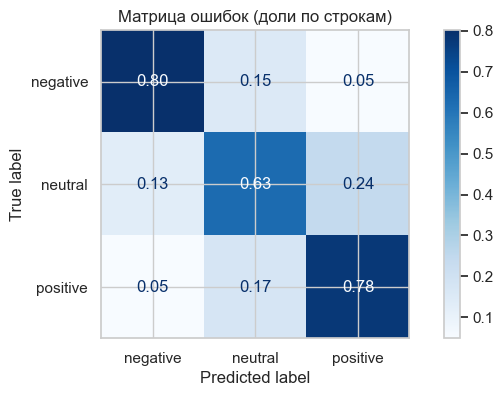

In [30]:
from sklearn.metrics import ConfusionMatrixDisplay

print(classification_report(y_test, best_pipe.predict(X_test)))

ConfusionMatrixDisplay.from_estimator(
    best_pipe, X_test, y_test, cmap='Blues', normalize='true', values_format='.2f',
)
plt.title('Матрица ошибок (доли по строкам)')
plt.show()

In [31]:
# смотрим на самые уверенные ошибки — там обычно и прячется правда о данных
proba = best_pipe.predict_proba(X_test)
prediction = best_pipe.predict(X_test)
confidence = proba.max(axis=1)

errors = [
    (confidence[i], y_test[i], prediction[i], X_test[i])
    for i in range(len(y_test)) if prediction[i] != y_test[i]
]
errors.sort(reverse=True, key=lambda x: x[0])

for conf, true, pred_label, text in errors[:3]:
    print(f'уверенность {conf:.2f} | правда: {true} | модель: {pred_label}')
    print(text[:400].replace('\n', ' '), '...\n')

уверенность 0.94 | правда: neutral | модель: negative
АСТАНА. КАЗИНФОРМ - Экс-министр национальной экономики Куандык Бишимбаев арестован, передает корреспондент МИА «Казинформ» со ссылкой на Национальное бюро по противодействию коррупции.     «12 января  с санкции районного суда №2 Алматинского района Астаны в отношении Куандыка Бишимбаева избрана мера пресечения «арест». Бишимбаев обвиняется в неоднократном получении взяток в особо крупном размере,  ...

уверенность 0.94 | правда: neutral | модель: negative
 «Самоочищение системы» напоминает подвиг барона Мюнхаузена, вытаскивающего себя за волосы из болота На снимке: Куандык Бишимбаев. * А как хорошо всё начиналось… * Мы живём в разных странах * Не менять систему, а встраиваться в неё * Дед Мороз совсем отморозился * Метод уробороса - Не огорчайся! - стал успокаивать его Сергей Олегович. - Уволят - работать пойдешь... - при этих словах Семенов как-то ...

уверенность 0.93 | правда: neutral | модель: positive
12 иностранных компаний ре

Типичная картина: длинная новость, где негатив упоминается в одном абзаце, а остальной текст нейтральный. Мешок слов усредняет весь документ и теряет этот абзац.

> **Что бы вы сделали?** Один из рабочих вариантов — классифицировать не весь текст, а первые N символов: в новостях суть обычно в лиде. Это одна из задач в конце.

---
## 8. Почему здесь не работают деревья ⏱ 7 мин

На прошлых семинарах деревья и лес обыгрывали линейные модели почти везде. На текстах всё переворачивается — проверим.

In [32]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC

vec = TfidfVectorizer(max_features=30_000, min_df=3)
A_train = vec.fit_transform(X_train)
A_test = vec.transform(X_test)

models = [
    ('MultinomialNB', MultinomialNB()),
    ('LogisticRegression', LogisticRegression(max_iter=1000, class_weight='balanced')),
    ('LinearSVC', LinearSVC(class_weight='balanced')),
    ('DecisionTree (depth=20)', DecisionTreeClassifier(max_depth=20, random_state=RANDOM_STATE)),
    ('RandomForest (100)', RandomForestClassifier(n_estimators=100, n_jobs=-1, random_state=RANDOM_STATE)),
]

rows = []
for name, model in models:
    t0 = time.time()
    model.fit(A_train, y_train)
    p = model.predict(A_test)
    rows.append({
        'модель': name,
        'f1_macro': round(f1_score(y_test, p, average='macro'), 3),
        'секунд': round(time.time() - t0, 1),
    })

pd.DataFrame(rows).sort_values('f1_macro', ascending=False)

,модель,f1_macro,секунд
2,LinearSVC,0.712,0.4
1,LogisticRegression,0.710,0.9
4,RandomForest (100),0.620,2.6
0,MultinomialNB,0.594,0.0
3,DecisionTree (depth=20),0.506,2.4


Линейные модели впереди с большим отрывом. Причина в геометрии задачи:

* признаков (30 000) в разы больше, чем объектов (6 600) — в таком пространстве классы почти всегда линейно разделимы;
* каждое дерево в сплите смотрит на **одно** слово, а сигнал размазан по сотням слов сразу; чтобы собрать его деревьями, нужна абсурдная глубина;
* матрица разреженная, и случайный выбор признаков в лесу почти всегда попадает в столбец из одних нулей.

Отсюда практическое правило: **на разреженных текстовых признаках начинайте с линейной модели, а градиентный бустинг приберегите для табличных данных.**

---
## Что дальше

Всё, что мы делали, — представления «до эмбеддингов». Мешок слов не знает, что «врач» и «доктор» — про одно и то же: для него это просто два разных столбца. Дальше в этом направлении:

* **word2vec / fastText** — плотные векторы слов, близкие по смыслу слова близки геометрически; fastText вдобавок собирает вектор из кусков слова, что выручает на русской морфологии;
* **трансформеры** (BERT и его русские родственники — `ruBERT`, `ruRoBERTa`) — вектор слова зависит от контекста, поэтому «замок» в «средневековый замок» и в «дверной замок» получат разные представления;
* готовые эмбеддинги предложений — например, `sentence-transformers`, где весь документ превращается в один вектор парой строк.

Сравнить их на этом же датасете — хорошая тема для домашнего эксперимента: TF-IDF даёт 0.71, и это на удивление крепкая планка. Нейросетевые модели обыгрывают её не всегда, а считаются на порядок дольше.

Полезное:

* [документация TfidfVectorizer](https://scikit-learn.org/stable/modules/generated/sklearn.feature_extraction.text.TfidfVectorizer.html)
* [Working with text data — гайд scikit-learn](https://scikit-learn.org/stable/tutorial/text_analytics/working_with_text_data.html)
* [Наташа](https://github.com/natasha/natasha) — набор инструментов для русского NLP

---
## Задачи для самостоятельной работы

#### Задача 1

Обучите бейзлайн не на всём тексте, а только на его начале (первые 500, 1000 и 2000 символов). Постройте график зависимости `f1_macro` от длины обрезки. Хватает ли лида, чтобы определить тональность?

In [33]:
# ваш код здесь

#### Задача 2

В блоке 5 мы выяснили, что лемматизация всего корпуса не помогает. Проверьте более аккуратную гипотезу: лемматизировать **только слова длиннее 6 символов**, короткие оставить как есть. Стало лучше бейзлайна?

In [34]:
# ваш код здесь

#### Задача 3

`TfidfVectorizer` умеет работать не со словами, а с символьными n-граммами: `analyzer='char_wb', ngram_range=(3, 5)`. Такие признаки устойчивы к опечаткам и к морфологии. Замерьте качество и время обучения — и решите, стоит ли оно того.

In [35]:
# ваш код здесь

#### Задача 4

Сведите задачу к бинарной: `negative` против всех остальных. Постройте precision-recall кривую и подберите порог так, чтобы recall негативного класса был не ниже 0.8. Какой ценой в precision это даётся?

> Подсказка: `predict_proba` даёт вероятности, `sklearn.metrics.precision_recall_curve` — кривую.

In [36]:
# ваш код здесь

#### Задача 5 (со звёздочкой)

В блоке 7 мы увидели, что модель цепляется за имена собственные. Отфильтруйте из словаря все токены, которые `pymorphy3` размечает как имя, фамилию или отчество (граммемы `Name`, `Surn`, `Patr`), переобучите модель и сравните метрику. Стала ли модель хуже — и что это говорит о том, чему она на самом деле научилась?

In [37]:
# ваш код здесь